# 6.86x - Introduction to ML Packages (Part 1)

Este tutorial foi elaborado para oferecer uma visão geral do cenário de pacotes de aprendizado de máquina (ML).
O objetivo não é apresentar uma explicação detalhada de todos os recursos de cada pacote, mas sim demonstrar a finalidade de alguns pacotes de ML amplamente utilizados. Para mais detalhes, recomendamos consultar a documentação dos pacotes e outros tutoriais online.

Você pode percorrer as seções sobre Jupyter, NumPy e Matplotlib antes do início do curso e, em seguida, começar a estudar as seções seguintes após concluir a Unidade 1.

https://github.com/varal7/ml-tutorial

## Jupyter

O [Jupyter](https://jupyter.org) não é, a rigor, um pacote de ML. Ele oferece uma interface de usuário (front-end) no navegador conectada a uma instância do IPython, permitindo o uso de REPL para testes rápidos e a criação de documentos que combinam código, saídas, imagens e texto. Isso é excelente para prototipagem, demonstrações e tutoriais, mas péssimo para a programação propriamente dita.

In [2]:
6 * 7

42

In [4]:
def tokenize(text):
    return text.split(" ")

In [5]:
text = "In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley"
print(tokenize(text))

['In', 'a', 'shocking', 'finding,', 'scientist', 'discovered', 'a', 'herd', 'of', 'unicorns', 'living', 'in', 'a', 'remote,', 'previously', 'unexplored', 'valley']


## Numpy

In [6]:
import numpy as np

O [Numpy](http://www.numpy.org) foi projetado para lidar com grandes arrays multidimensionais e permitir a realização de cálculos eficientes com eles. Internamente, ele executa código C pré-compilado, que é muito mais rápido do que, por exemplo, um loop `for` do Python.

No tutorial do NumPy, abordamos os fundamentos do NumPy, arrays do NumPy, operações elemento a elemento, operações com matrizes e a geração de matrizes aleatórias.
Nesta seção, abordaremos indexação, fatiamento (*slicing*) e *broadcasting* — conceitos úteis que serão reutilizados no `Pandas` e no `PyTorch`.

### Indexing and slicing

Arrays do NumPy podem ser indexados e fatiados como arrays comuns do Python.

In [7]:
a_py = [1, 2, 3, 4, 5, 6, 7, 8, 9]
a_np = np.array(a_py)

In [8]:
print(a_py[3:7:2], a_np[3:7:2])
print(a_py[2:-1:2], a_np[2:-1:2])
print(a_py[::-1], a_np[::-1])

[4, 6] [4 6]
[3, 5, 7] [3 5 7]
[9, 8, 7, 6, 5, 4, 3, 2, 1] [9 8 7 6 5 4 3 2 1]


Mas você também pode usar arrays para indexar outros arrays.

In [9]:
idx = np.array([7, 2])
a_np[idx]

array([8, 3])

In [ ]:
# a_py[idx]

O que permite realizar consultas, reindexações e até mesmo ordenações de forma conveniente.

In [15]:
ages = np.random.randint(low=30, high=60, size=10)
heights = np.random.randint(low=150, high=210, size=10)

print(ages)
print(heights)

[43 48 56 51 43 50 50 49 49 30]
[182 167 158 150 172 150 205 185 162 181]


In [16]:
print(ages < 50)

[ True  True False False  True False False  True  True  True]


In [17]:
print(heights[ages < 50])
print(ages[ages < 50])

[182 167 172 185 162 181]
[43 48 43 49 49 30]


In [18]:
shuffled_idx = np.random.permutation(10)
print(shuffled_idx)
print(ages[shuffled_idx])
print(heights[shuffled_idx])

[9 6 2 1 7 8 5 0 4 3]
[30 50 56 48 49 49 50 43 43 51]
[181 205 158 167 185 162 150 182 172 150]


In [19]:
sorted_idx = np.argsort(ages)
print(sorted_idx)
print(ages[sorted_idx])
print(heights[sorted_idx])

[9 0 4 1 8 7 5 6 3 2]
[30 43 43 48 49 49 50 50 51 56]
[181 182 172 167 162 185 150 205 150 158]


### Broadcasting

Quando o NumPy é solicitado a realizar uma operação entre arrays de tamanhos diferentes, ele faz o "broadcast" do array menor para o maior.

In [20]:
a = np.array([4, 5, 6])
b = np.array([2, 2, 2])
a * b

array([ 8, 10, 12])

In [21]:
a = np.array([4, 5, 6])
b = 2
a * b

array([ 8, 10, 12])

Os dois trechos de código acima são equivalentes, mas o segundo é mais fácil de ler e também mais eficiente.

In [22]:
a = np.arange(10).reshape(1, 10)
b = np.arange(12).reshape(12, 1)

In [23]:
print(a)
print(b)

[[0 1 2 3 4 5 6 7 8 9]]
[[ 0]
 [ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]]


In [24]:
print(a * b)

[[ 0  0  0  0  0  0  0  0  0  0]
 [ 0  1  2  3  4  5  6  7  8  9]
 [ 0  2  4  6  8 10 12 14 16 18]
 [ 0  3  6  9 12 15 18 21 24 27]
 [ 0  4  8 12 16 20 24 28 32 36]
 [ 0  5 10 15 20 25 30 35 40 45]
 [ 0  6 12 18 24 30 36 42 48 54]
 [ 0  7 14 21 28 35 42 49 56 63]
 [ 0  8 16 24 32 40 48 56 64 72]
 [ 0  9 18 27 36 45 54 63 72 81]
 [ 0 10 20 30 40 50 60 70 80 90]
 [ 0 11 22 33 44 55 66 77 88 99]]


## Matplotlib


In [25]:
%matplotlib inline
import matplotlib.pyplot as plt

In [26]:
plt.rcParams['figure.figsize'] = [10, 7]

O [Matplotlib](https://matplotlib.org) é a biblioteca de referência para criar gráficos com Python. Ele oferece duas APIs: uma semelhante ao MATLAB, que muitas pessoas aprenderam a usar e adoram, e uma API orientada a objetos, cujo uso recomendamos.

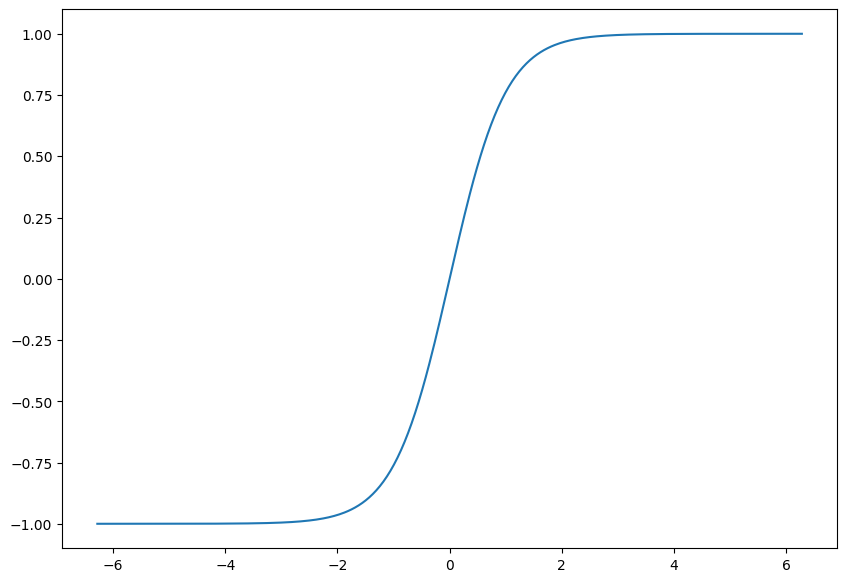

In [27]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 400)
y = np.tanh(x)
fig, ax = plt.subplots()
ax.plot(x, y)

Você pode traçar múltiplos subgráficos na mesma figura, ou múltiplas funções no mesmo subgráfico.

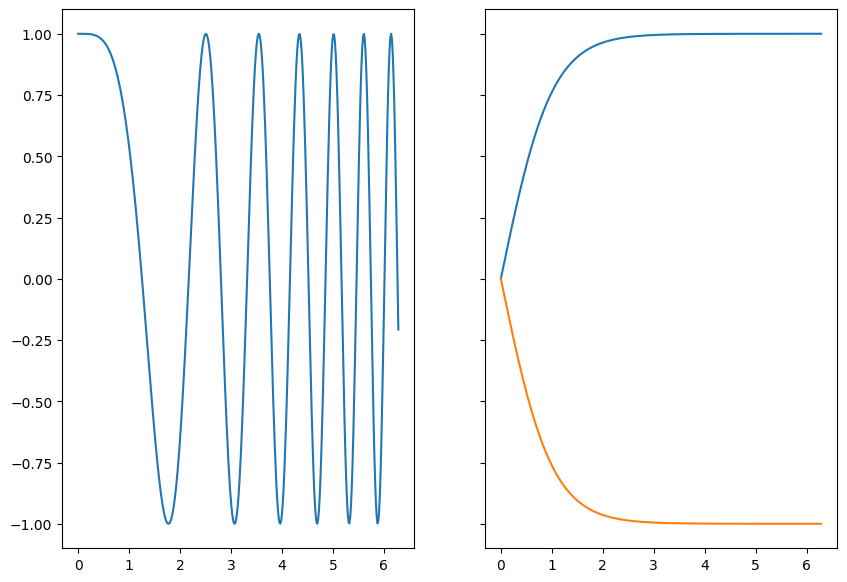

In [28]:
x = np.linspace(0, 2 * np.pi, 400)
y1 = np.tanh(x)
y2 = np.cos(x**2)
fig, axes = plt.subplots(1, 2, sharey=True)
axes[1].plot(x, y1)
axes[1].plot(x, -y1)
axes[0].plot(x, y2)

O Matplotlib também oferece diversas opções de personalização para cores, rótulos, eixos, etc.

Por exemplo, veja esta [introdução ao Matplotlib](https://nbviewer.jupyter.org/github/jrjohansson/scientific-python-lectures/blob/master/Lecture-4-Matplotlib.ipynb)

## Scikit-learn (read this after you have completed unit 1)

O [Scikit-learn](https://scikit-learn.org/) inclui diversos recursos e utilitários para dar início à sua jornada em Machine Learning.

### A toy example

In [29]:
from sklearn.datasets import make_blobs

In [30]:
X, y = make_blobs(n_samples=1000, centers=2, random_state=0)
X[:5], y[:5]

(array([[0.4666179 , 3.86571303],
        [2.84382807, 3.32650945],
        [0.61121486, 2.51245978],
        [3.81653365, 1.65175932],
        [1.28097244, 0.62827388]]),
 array([0, 0, 0, 1, 1]))

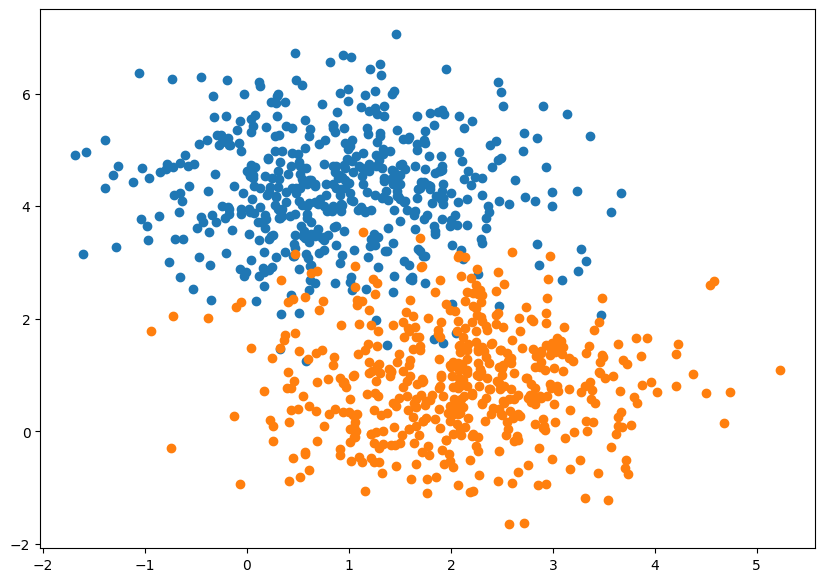

In [31]:
fig, ax = plt.subplots()
for label in [0, 1]:
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1])

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

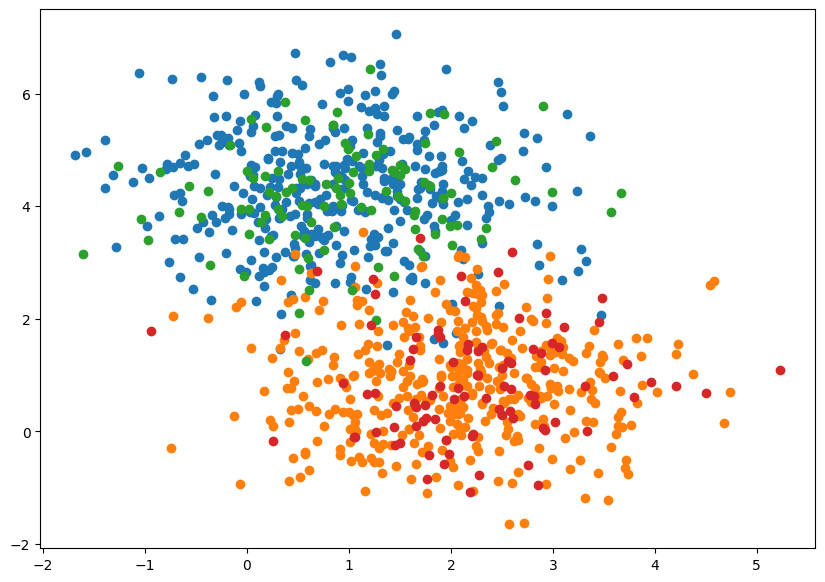

In [34]:
fig, ax = plt.subplots()
for label in [0, 1]:
    mask = y_train == label
    ax.scatter(X_train[mask, 0], X_train[mask, 1])
for label in [0, 1]:
    mask = y_test == label
    ax.scatter(X_test[mask, 0], X_test[mask, 1])

O Sklearn utiliza uma API uniforme e muito consistente, o que facilita a troca de algoritmos.

Por exemplo, treinar e realizar previsões com um perceptron.

In [29]:
from sklearn.linear_model import Perceptron
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

In [30]:
clf = Perceptron(max_iter=40, random_state=0)
# clf = LinearSVC(max_iter=40, random_state=0)

In [31]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Test accuracy: %.4f' % accuracy_score(y_test, y_pred))

Test accuracy: 0.9250


In [32]:
theta = clf.coef_[0]
theta_0 = clf.intercept_

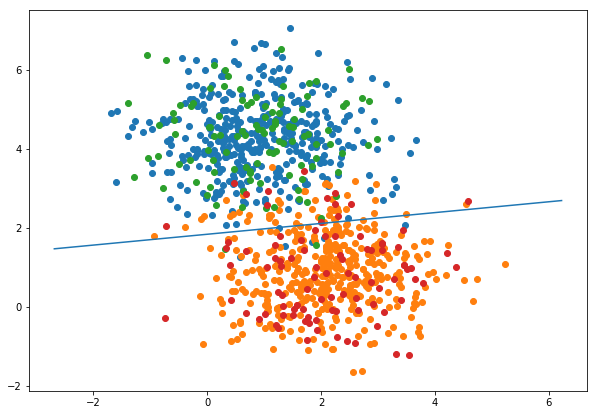

In [33]:
fig, ax = plt.subplots()
for label in [0, 1]:
    mask = y_train == label
    ax.scatter(X_train[mask, 0], X_train[mask, 1])
for label in [0, 1]:
    mask = y_test == label
    ax.scatter(X_test[mask, 0], X_test[mask, 1])
x_bnd = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 400)
y_bnd = -x_bnd * (theta[0] / theta[1]) - (theta_0 / theta[1])
ax.plot(x_bnd, y_bnd)

### Another toy example

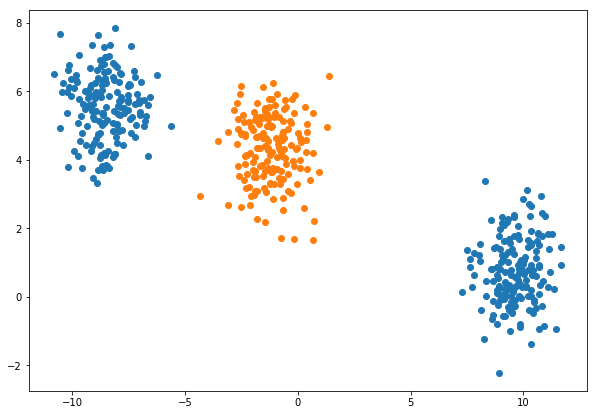

In [34]:
X, y = make_blobs(n_samples=500, centers=3, random_state=7)
y[y == 2] = 0
fig, ax = plt.subplots()
for label in [0, 1]:
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1])

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [36]:
from sklearn.svm import SVC

# clf = SVC(kernel="linear", random_state=0)
clf = SVC(kernel="rbf", random_state=0)
clf.fit(X_train, y_train)

SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=0, shrinking=True,
  tol=0.001, verbose=False)

In [37]:
y_pred = clf.predict(X_test)

print('Test accuracy: %.4f' % accuracy_score(y_test, y_pred))

Test accuracy: 1.0000


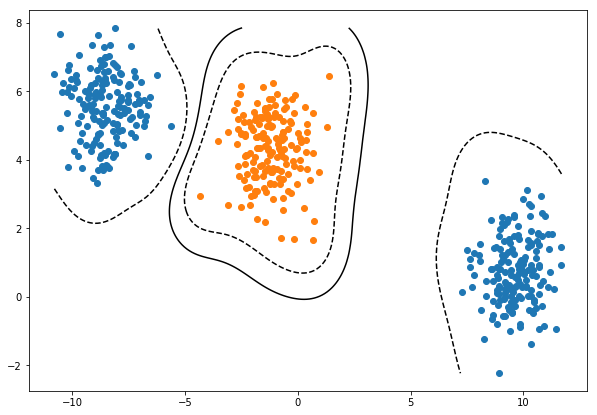

In [38]:
x_min = X[:, 0].min()
x_max = X[:, 0].max()
y_min = X[:, 1].min()
y_max = X[:, 1].max()

XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])

fig, ax = plt.subplots()
for label in [0, 1]:
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1])

Z = Z.reshape(XX.shape)
ax.contour(
    XX, YY, Z, colors="black", linestyles=['--', '-', '--'], levels=[-0.5, 0, 0.5]
)

### Classify digits

In [39]:
# from sklearn.datasets import load_breast_cancer
# breast_cancer = load_breast_cancer()
# X, y = breast_cancer.data, breast_cancer.target
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [40]:
from sklearn.datasets import load_digits

In [41]:
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

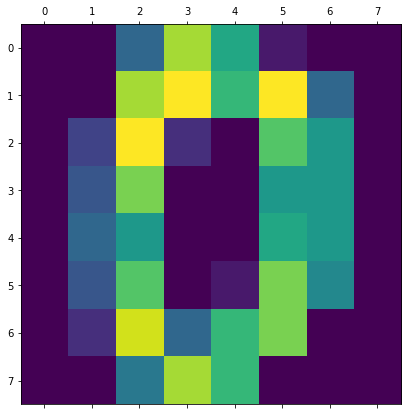

In [42]:
fig, ax = plt.subplots()
ax.matshow(digits.images[0])

In [43]:
X_train.shape

(1437, 64)

In [44]:
clf = Perceptron(max_iter=40, random_state=0)

In [45]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('Accuracy: %.4f' % accuracy_score(y_test, y_pred))

Accuracy: 0.9389


In [46]:
clf = LinearSVC(C=1, random_state=0)

In [47]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('Accuracy: %.4f' % accuracy_score(y_test, y_pred))

Accuracy: 0.9361


In [48]:
from sklearn.metrics import confusion_matrix

In [49]:
confusion_matrix(y_test, clf.predict(X_test))

array([[27,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 29,  0,  0,  0,  0,  1,  0,  5,  0],
       [ 0,  1, 33,  2,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 29,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 30,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  0,  0, 38,  1,  0,  0,  0],
       [ 0,  1,  0,  0,  0,  0, 43,  0,  0,  0],
       [ 0,  2,  0,  0,  0,  0,  0, 37,  0,  0],
       [ 0,  2,  1,  0,  0,  0,  0,  0, 35,  1],
       [ 0,  0,  0,  2,  0,  1,  0,  0,  2, 36]])

O Scikit-learn também inclui utilitários para calcular rapidamente uma pontuação de validação cruzada...

In [50]:
clf = LinearSVC(C=1, random_state=0)
from sklearn.model_selection import cross_val_score

scores = cross_val_score(clf, X_train, y_train, cv=5)
print("Mean: %.4f, Std: %.4f" % (np.mean(scores), np.std(scores)))

Mean: 0.9443, Std: 0.0127


In [51]:
clf = LinearSVC(C=0.1, random_state=0)
scores = cross_val_score(clf, X_train, y_train, cv=5)
print("Mean: %.4f, Std: %.4f" % (np.mean(scores), np.std(scores)))

Mean: 0.9555, Std: 0.0101


... ou para realizar uma busca em grade

In [52]:
from sklearn.model_selection import GridSearchCV

In [53]:
clf = LinearSVC(random_state=0)
param_grid = {'C': 10.0 ** np.arange(-6, 4)}
grid_search = GridSearchCV(
    clf, param_grid=param_grid, cv=5, verbose=3, return_train_score=True
)

In [54]:
grid_search.fit(X_train, y_train);

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] C=1e-06 .........................................................
[CV] ................ C=1e-06, score=0.8424657534246576, total=   0.0s
[CV] C=1e-06 .........................................................
[CV] ................ C=1e-06, score=0.8719723183391004, total=   0.0s
[CV] C=1e-06 .........................................................
[CV] ................ C=1e-06, score=0.9090909090909091, total=   0.0s
[CV] C=1e-06 .........................................................
[CV] ................ C=1e-06, score=0.8426573426573427, total=   0.0s
[CV] C=1e-06 .........................................................
[CV] ................. C=1e-06, score=0.897887323943662, total=   0.0s
[CV] C=1e-05 .........................................................
[CV] ................ C=1e-05, score=0.9075342465753424, total=   0.0s
[CV] C=1e-05 .........................................................
[CV] ...........

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s


[CV] ................. C=0.001, score=0.958904109589041, total=   0.0s
[CV] C=0.001 .........................................................
[CV] ................ C=0.001, score=0.9653979238754326, total=   0.0s
[CV] C=0.001 .........................................................
[CV] ................. C=0.001, score=0.965034965034965, total=   0.0s
[CV] C=0.001 .........................................................
[CV] ................. C=0.001, score=0.965034965034965, total=   0.0s
[CV] C=0.001 .........................................................
[CV] ................ C=0.001, score=0.9788732394366197, total=   0.0s
[CV] C=0.01 ..........................................................
[CV] ................. C=0.01, score=0.9554794520547946, total=   0.1s
[CV] C=0.01 ..........................................................
[CV] ................. C=0.01, score=0.9619377162629758, total=   0.1s
[CV] C=0.01 ..........................................................
[CV] .

[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    2.5s finished


In [55]:
print(grid_search.best_params_)

{'C': 0.001}


In [56]:
print(grid_search.best_score_)

0.9665970772442589


In [57]:
y_pred = grid_search.predict(X_test)
print('Accuracy: %.4f' % accuracy_score(y_test, y_pred))

Accuracy: 0.9639


E muito mais recursos!  
Analisamos apenas alguns modelos de classificação e alguns recursos de seleção de modelos, mas o sklearn também pode ser usado para regressão.

## Pandas

In [58]:
import pandas as pd

O [Pandas](http://pandas.pydata.org) é uma biblioteca que fornece um conjunto de ferramentas para análise de dados (Python Data Analysis Library).

DataFrames do Pandas podem ser criados importando um arquivo CSV (ou TSV, JSON, SQL, etc.).

In [59]:
# df = pd.read_csv("file.csv")

DataFrames do Pandas também podem ser criados diretamente a partir de um dicionário de arrays.

In [60]:
print(grid_search.cv_results_)

{'mean_fit_time': array([0.01142702, 0.01115093, 0.01050925, 0.02054195, 0.07160912,
       0.06751108, 0.06907425, 0.06755571, 0.07172804, 0.07606635]), 'std_fit_time': array([0.00053882, 0.00038095, 0.00030056, 0.0004086 , 0.00281235,
       0.00261869, 0.00117984, 0.00326013, 0.00573768, 0.0030746 ]), 'mean_score_time': array([0.00030556, 0.00029874, 0.00025778, 0.00029097, 0.00029759,
       0.00030074, 0.00031796, 0.00030222, 0.00032935, 0.00035524]), 'std_score_time': array([4.90965395e-05, 1.10162491e-04, 3.79735462e-05, 3.75066905e-05,
       4.90331443e-06, 1.30740366e-05, 3.27037297e-05, 1.36716789e-05,
       3.10957060e-05, 4.44746199e-05]), 'param_C': masked_array(data=[1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0,
                   100.0, 1000.0],
             mask=[False, False, False, False, False, False, False, False,
                   False, False],
       fill_value='?',
            dtype=object), 'params': [{'C': 1e-06}, {'C': 1e-05}, {'C': 0.0001}, {'C': 0.0

In [61]:
df = pd.DataFrame(grid_search.cv_results_)
df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.011427,0.000539,0.000306,0.000049,1e-06,{'C': 1e-06},0.842466,0.871972,0.909091,0.842657,...,0.872651,0.027467,10,0.882969,0.880662,0.869679,0.881842,0.872507,0.877532,0.005383
1,0.011151,0.000381,0.000299,0.000110,1e-05,{'C': 1e-05},0.907534,0.913495,0.944056,0.902098,...,0.919972,0.015905,9,0.929258,0.931185,0.922676,0.932233,0.925412,0.928153,0.003594
2,0.010509,0.000301,0.000258,0.000038,0.0001,{'C': 0.0001},0.934932,0.941176,0.965035,0.940559,...,0.949896,0.013812,4,0.963319,0.964286,0.960035,0.960904,0.958369,0.961382,0.002159
3,0.020542,0.000409,0.000291,0.000038,0.001,{'C': 0.001},0.958904,0.965398,0.965035,0.965035,...,0.966597,0.006563,1,0.982533,0.982578,0.983493,0.980017,0.981787,0.982082,0.001165
4,0.071609,0.002812,0.000298,0.000005,0.01,{'C': 0.01},0.955479,0.961938,0.968531,0.961538,...,0.963814,0.005743,2,0.993886,0.993031,0.994787,0.992181,0.993929,0.993563,0.000887
5,0.067511,0.002619,0.000301,0.000013,0.1,{'C': 0.1},0.945205,0.972318,0.947552,0.961538,...,0.955463,0.010139,3,0.998253,0.996516,0.998262,0.996525,0.995663,0.997044,0.001039
6,0.069074,0.001180,0.000318,0.000033,1,{'C': 1.0},0.941781,0.961938,0.937063,0.954545,...,0.944328,0.012686,6,0.997380,0.997387,0.997394,0.995656,0.980919,0.993747,0.006449
7,0.067556,0.003260,0.000302,0.000014,10,{'C': 10.0},0.938356,0.965398,0.933566,0.951049,...,0.948504,0.011423,5,0.994760,0.992160,0.994787,0.991312,0.990460,0.992696,0.001780
8,0.071728,0.005738,0.000329,0.000031,100,{'C': 100.0},0.928082,0.944637,0.933566,0.947552,...,0.938761,0.007159,8,0.995633,0.989547,0.995656,0.987837,0.991327,0.992000,0.003174
9,0.076066,0.003075,0.000355,0.000044,1000,{'C': 1000.0},0.938356,0.955017,0.930070,0.954545,...,0.944328,0.009568,6,0.996507,0.984321,0.995656,0.993918,0.987858,0.991652,0.004751


As colunas do Pandas também são arrays do NumPy, portanto, seguem a mesma "mágica" de indexação.

In [62]:
df[df['param_C'] < 0.01]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.011427,0.000539,0.000306,0.000049,1e-06,{'C': 1e-06},0.842466,0.871972,0.909091,0.842657,...,0.872651,0.027467,10,0.882969,0.880662,0.869679,0.881842,0.872507,0.877532,0.005383
1,0.011151,0.000381,0.000299,0.000110,1e-05,{'C': 1e-05},0.907534,0.913495,0.944056,0.902098,...,0.919972,0.015905,9,0.929258,0.931185,0.922676,0.932233,0.925412,0.928153,0.003594
2,0.010509,0.000301,0.000258,0.000038,0.0001,{'C': 0.0001},0.934932,0.941176,0.965035,0.940559,...,0.949896,0.013812,4,0.963319,0.964286,0.960035,0.960904,0.958369,0.961382,0.002159
3,0.020542,0.000409,0.000291,0.000038,0.001,{'C': 0.001},0.958904,0.965398,0.965035,0.965035,...,0.966597,0.006563,1,0.982533,0.982578,0.983493,0.980017,0.981787,0.982082,0.001165


Eles também oferecem a maioria das funcionalidades que você esperaria como usuário de banco de dados (`df.sort_values`, `df.groupby`, `df.join`, `df.concat`, etc.).

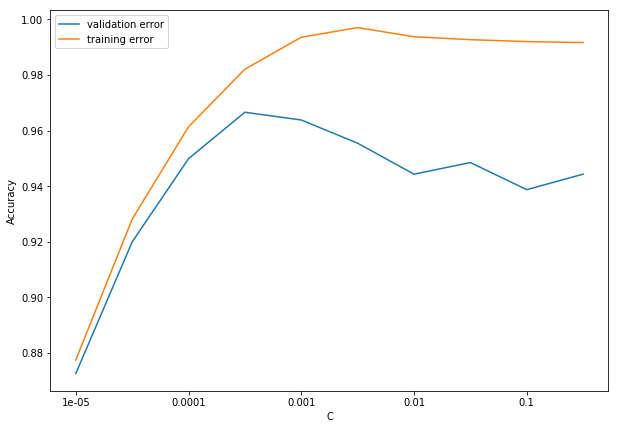

In [63]:
fig, ax = plt.subplots()
ax.plot(df['mean_test_score'], label="validation error")
ax.plot(df['mean_train_score'], label="training error")
ax.set_xticklabels(df['param_C'])
ax.set_xlabel("C")
ax.set_ylabel("Accuracy")
ax.legend(loc='best');

## Other packages 

Outros pacotes que ficaram de fora:
- [Plotly](https://plot.ly) e [Seaborn](http://seaborn.pydata.org): duas outras bibliotecas de visualização de dados
- [Scipy](https://www.scipy.org): uma biblioteca científica construída sobre o NumPy
- [Scrapy](https://www.scipy.org): uma biblioteca de *web crawling*
- [pdb](https://docs.python.org/3/library/pdb.html): um depurador para Python (não específico para ML, mas extremamente útil)
- [tqdm](https://github.com/tqdm/tqdm): uma barra de progresso (não específica para ML)

Na próxima:
- [Pytorch](https://pytorch.org)